In [1]:
import torch
import numpy as np
import seaborn as sns

from chess import Board
from numpy.random import default_rng
from IPython.display import Image, display

import sys

sys.path.append('../src')

import ctypes.util
print("cairo ->", ctypes.util.find_library("cairo"))

import os
os.environ['DYLD_FALLBACK_LIBRARY_PATH'] = "/opt/homebrew/lib:" + os.environ.get('DYLD_FALLBACK_LIBRARY_PATH','')
import cairosvg  # now it should find libcairo

from games.chess import KRK
from AlphaZero.alpha_zero import GameSearchTree, SelfPlay
from agents.utils import ChessEncoder
from agents.random_agent import RandomAgent
from agents.random_policy import GameUniformPolicy
from games.game_utils import GymEnvFromGameAndPlayer2


cairo -> /opt/homebrew/lib/libcairo.dylib


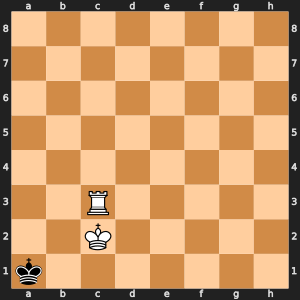

In [2]:
seed = 4
rng = default_rng(seed)
start_position = 1
game = KRK(start_position=start_position)
random_policy = GameUniformPolicy(
    game=game,
    rng=rng,
    encoder=None
)

pl2 = RandomAgent(
    policy=random_policy,
    rng=rng
)
encoder = ChessEncoder()
env = GymEnvFromGameAndPlayer2(
    game=game,
    other_player=pl2,
    encoder=encoder
)
self_play = SelfPlay(
    start_position=start_position,
    puct_constant=1,
)
self_play.debug = True
self_play.game.render(self_play.tree.root.state)

We are here:
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . R . . . . .
. . K . . . . .
k . . . . . . .
Best action: c3a3


/Users/edgar/Documents/GitHub/ChessFinalistMCTS/notebooks/../src/AlphaZero/alpha_zero.py:653: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(state, dtype=torch.float32).to(self.device),


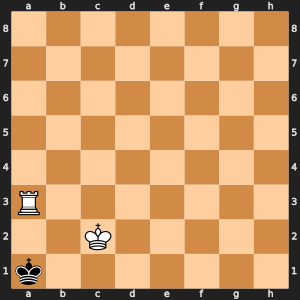

In [3]:
self_play.tree.get_best_root_action()
self_play.step()
self_play.game.render(self_play.tree.root.state)

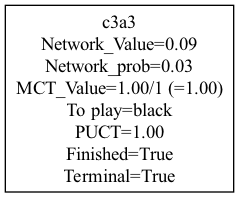

In [4]:
png_data = self_play.tree.to_pydot().create_png()
display(Image(png_data))

In [5]:
board = self_play.tree.root.state
check_final = self_play.game.is_terminal(board)
print("Is terminal?", check_final)
if check_final:
    print(f"{self_play.game.utility(board)}")

Is terminal? True
1


In [6]:
self_play.run_timesteps()

Reward: 1
Game reset to position 2:
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . R . . . . .
k . K . . . . .
. . . . . . . .
We are here:
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . R . . . . .
k . K . . . . .
. . . . . . . .
Best action: c3c6


/Users/edgar/Documents/GitHub/ChessFinalistMCTS/notebooks/../src/AlphaZero/alpha_zero.py:653: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(state, dtype=torch.float32).to(self.device),


We are here:
. . . . . . . .
. . . . . . . .
. . R . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
k . K . . . . .
. . . . . . . .
Best action: a2a3
We are here:
. . . . . . . .
. . . . . . . .
. . R . . . . .
. . . . . . . .
. . . . . . . .
k . . . . . . .
. . K . . . . .
. . . . . . . .
Best action: c6f6
We are here:
. . . . . . . .
. . . . . . . .
. . . . . R . .
. . . . . . . .
. . . . . . . .
k . . . . . . .
. . K . . . . .
. . . . . . . .
Best action: a3b4
[Timestep 5] Iniciando fase de entrenamiento...
log_probs: torch.Size([4, 30])
target_pi: torch.Size([4, 30])
value_loss=0.0583 | policy_loss=-0.0000 | total=0.1096
log_probs: torch.Size([1, 30])
target_pi: torch.Size([1, 30])
value_loss=0.0286 | policy_loss=-0.0000 | total=0.0792
log_probs: torch.Size([4, 30])
target_pi: torch.Size([4, 30])
value_loss=0.5695 | policy_loss=-0.0000 | total=0.6196
log_probs: torch.Size([1, 30])
target_pi: torch.Size([1, 30])
value_loss=0.2588 | policy_loss=-0.0000 | total=0.3083
We are 

In [7]:
self_play.tree.get_best_root_action()
self_play.game.render(self_play.tree.root.state)

IndexError: pop from empty PriorityQueue

<Axes: >

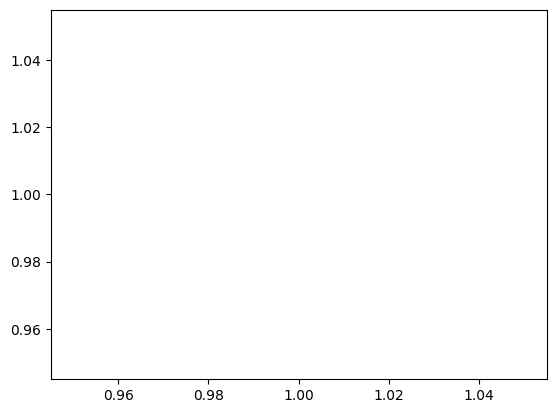

In [8]:
sns.lineplot(
    x=range(1, len(self_play.rewards) + 1),
    y=self_play.rewards
)

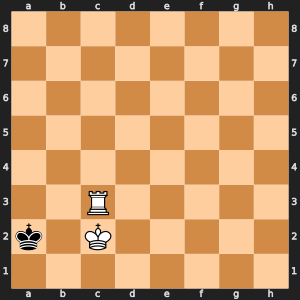

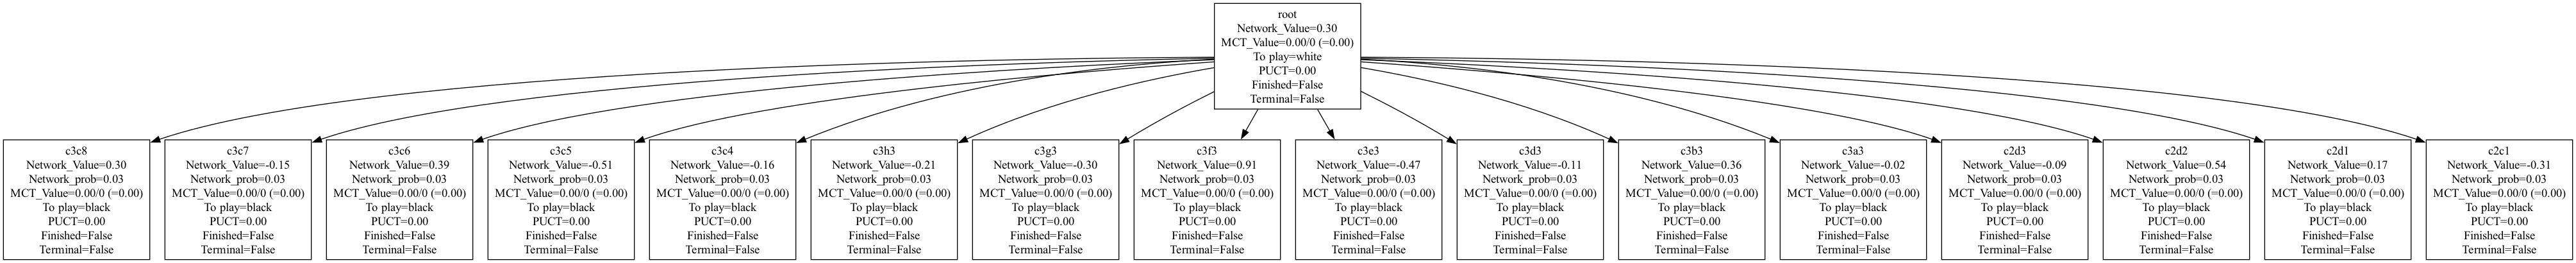

In [9]:
self_play.reset_game(start_position=2)
self_play.game.render(self_play.tree.root.state)
png_data = self_play.tree.to_pydot().create_png()
display(Image(png_data))

In [ ]:
self_play.tree.get_v(self_play.tree.root)

0.054283566772937775